### Adapt workflow from hic-spermatogenesis

The workflow was adapted to work with NCBI (the assembly is not yet on UCSC)


Use MultiQC to visualize the dedup and mapping steps


In [19]:
%%bash 

mkdir ../data/multiqc/

for dir in $(ls ../steps/pairs/); do
    echo $dir
    multiqc -i $dir -o ../data/multiqc/ -d ../steps/pairs/$dir 
    echo ""

done


fibroblast



/// ]8;id=777633;https://multiqc.info\MultiQC]8;;\ 🔍 v1.25.1

     update_config | Report title: fibroblast
     update_config | Prepending directory to sample names
     version_check | MultiQC Version v1.29 now available!
       file_search | Search path: /faststorage/project/hic-spermatogenesis/people/sojern/hic-compartment-borders/steps/pairs/fibroblast
         searching | ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 42/42  42  
         pairtools | Found 7 reports
     write_results | Data        : /faststorage/project/hic-spermatogenesis/people/sojern/hic-compartment-borders/data/multiqc/fibroblast_multiqc_report_data
     write_results | Report      : /faststorage/project/hic-spermatogenesis/people/sojern/hic-compartment-borders/data/multiqc/fibroblast_multiqc_report.html
           multiqc | MultiQC complete



pachytene_spermatocyte



/// ]8;id=723026;https://multiqc.info\MultiQC]8;;\ 🔍 v1.25.1

     update_config | Report title: pachytene_spermatocyte
     update_config | Prepending directory to sample names
     version_check | MultiQC Version v1.29 now available!
       file_search | Search path: /faststorage/project/hic-spermatogenesis/people/sojern/hic-compartment-borders/steps/pairs/pachytene_spermatocyte
         searching | ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 36/36  36  
         pairtools | Found 6 reports
     write_results | Data        : /faststorage/project/hic-spermatogenesis/people/sojern/hic-compartment-borders/data/multiqc/pachytene_spermatocyte_multiqc_report_data
     write_results | Report      : /faststorage/project/hic-spermatogenesis/people/sojern/hic-compartment-borders/data/multiqc/pachytene_spermatocyte_multiqc_report.html
           multiqc | MultiQC complete



round_spermatid



/// ]8;id=454410;https://multiqc.info\MultiQC]8;;\ 🔍 v1.25.1

     update_config | Report title: round_spermatid
     update_config | Prepending directory to sample names
     version_check | MultiQC Version v1.29 now available!
       file_search | Search path: /faststorage/project/hic-spermatogenesis/people/sojern/hic-compartment-borders/steps/pairs/round_spermatid
         searching | ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 36/36  sm  
         pairtools | Found 6 reports
     write_results | Data        : /faststorage/project/hic-spermatogenesis/people/sojern/hic-compartment-borders/data/multiqc/round_spermatid_multiqc_report_data
     write_results | Report      : /faststorage/project/hic-spermatogenesis/people/sojern/hic-compartment-borders/data/multiqc/round_spermatid_multiqc_report.html
           multiqc | MultiQC complete



sperm



/// ]8;id=414573;https://multiqc.info\MultiQC]8;;\ 🔍 v1.25.1

     update_config | Report title: sperm
     update_config | Prepending directory to sample names
     version_check | MultiQC Version v1.29 now available!
       file_search | Search path: /faststorage/project/hic-spermatogenesis/people/sojern/hic-compartment-borders/steps/pairs/sperm
         searching | ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 30/30  30  
         pairtools | Found 5 reports
     write_results | Data        : /faststorage/project/hic-spermatogenesis/people/sojern/hic-compartment-borders/data/multiqc/sperm_multiqc_report_data
     write_results | Report      : /faststorage/project/hic-spermatogenesis/people/sojern/hic-compartment-borders/data/multiqc/sperm_multiqc_report.html
           multiqc | MultiQC complete



spermatogonia



/// ]8;id=139413;https://multiqc.info\MultiQC]8;;\ 🔍 v1.25.1

     update_config | Report title: spermatogonia
     update_config | Prepending directory to sample names
     version_check | MultiQC Version v1.29 now available!
       file_search | Search path: /faststorage/project/hic-spermatogenesis/people/sojern/hic-compartment-borders/steps/pairs/spermatogonia
         searching | ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 42/42  42  
         pairtools | Found 7 reports
     write_results | Data        : /faststorage/project/hic-spermatogenesis/people/sojern/hic-compartment-borders/data/multiqc/spermatogonia_multiqc_report_data
     write_results | Report      : /faststorage/project/hic-spermatogenesis/people/sojern/hic-compartment-borders/data/multiqc/spermatogonia_multiqc_report.html
           multiqc | MultiQC complete


### Rename chromosomes from accessions to chromosomes

Use the assembly information file from NCBI

In [1]:
import cooler
import pandas as pd
import glob

%config InlineBackend.figure_format = 'retina'



In [ ]:

mclrs = glob.glob("../steps/cool/*/*.merged.mcool")
clrs = [f"{mcl}::{res}" for mcl in mclrs for res in cooler.fileops.list_coolers(mcl)]

# Locate the assembly report
report = "../steps/ref/T2T-MMU8v1.0/assembly_report.txt"

rep = pd.read_csv(report, sep="\t")
length = rep[["Sequence-Length","Sequence-Name"]]
rep_dict = rep.set_index("GenBank-Accn")["Sequence-Name"].to_dict()
inv_dict = rep.set_index("Sequence-Name")["GenBank-Accn"].to_dict()


for clr in clrs:
    tmp_clr = cooler.Cooler(clr)
    cooler.rename_chroms(tmp_clr, rep_dict)



### Calculate the GC content 

of the binned versions of the assembly (according to resolutions in mcool).

I will try to use the CLI to make quick work of it.

It is used as the phasing track for the eigendecomposition.


In [ ]:
%%bash 

REF=../steps/ref/T2T-MMU8v1.0/T2T-MMU8v1.0.renamed.fa

for res in 1000 5000 10000 50000 100000; do
    BINS=../data/bins/t2tbins.${res}.tsv
    GC_OUT=../data/bins/gc.${res}.tsv
    cooltools genome gc $BINS $REF > $GC_OUT
done

### Infer the centromeres

I found a `T2T-MMU8v1repeatMasker.out.gz` file and placed it `../steps/ref/T2T-MMU8v1/`, then extracted information about longest stretches of satellite repeats. 


In [ ]:
%%bash 

# Navigate
cd ../steps/ref/T2T-MMU8v1.0

# Download repeatmasker output 
wget https://hgdownload.soe.ucsc.edu/hubs/GCA/049/350/105/GCA_049350105.1/GCA_049350105.1.repeatMasker.out.gz .

# Find all the satellite repeats in the assembly
zcat GCA_049350105.1.repeatMasker.out.gz | \
awk 'NR > 3 && $11 ~ /[Ss]atellite/ { print $5, $6-1, $7, $10 }' OFS='\t' > satellite_repeats.bed

# Find the satellite repeats on chrX
zcat GCA_049350105.1.repeatMasker.out.gz | \
awk 'NR > 3 && $5 == "CM111679.1" && $11 ~ /[Ss]atellite/ { print $5, $6-1, $7, $10 }' OFS="\t" > chrX_satellites.bed

# Merge the satellite repeats to find the centromere
bedtools sort -i chrX_satellites.bed | \
bedtools merge -d 20000 -c 4 -o distinct > chrX_centromere.bed

# Find the largest satellite repeat
awk '{ print $0, $3 - $2 }' chrX_centromere.bed | sort -k5,5nr | head -n1

### Plot the satellites along the genome

In [1]:
import pandas as pd

satellites = pd.read_csv("../steps/ref/T2T-MMU8v1.0/chrX_centromere.bed", sep="\t",names=['chrom', 'start', 'end', 'type'])

satellites = satellites.assign(length = satellites['end'] - satellites['start'])


In [2]:
import matplotlib.pyplot as plt
import matplotlib_inline
import numpy as np
from matplotlib.patches import Rectangle

plt.style.use('smaller.mplstyle')
matplotlib_inline.backend_inline.set_matplotlib_formats('retina')

def plot_intervals(intervals, **kwargs):
    f, ax = plt.subplots(figsize=(6, 1), sharex=True)
    for start, end in zip(intervals['start'], intervals['end']):
        rect = Rectangle((start, 0.1), width=end-start, height=0.9, color='tab:red', linewidth=0, **kwargs)
        ax.add_patch(rect)
    ax.spines[:].set_visible(False)
    ax.spines['bottom'].set_visible(True)

    ax.set_yticks([])
    ticks = np.linspace(0, intervals['end'].max(), num=15)
    ax.set_xticks(ticks) 
    ax.set_xticklabels([f'{int(t/1e6)}' for t in ticks])
    ax.set_xlabel("Position (Mbp)")
    f.tight_layout()


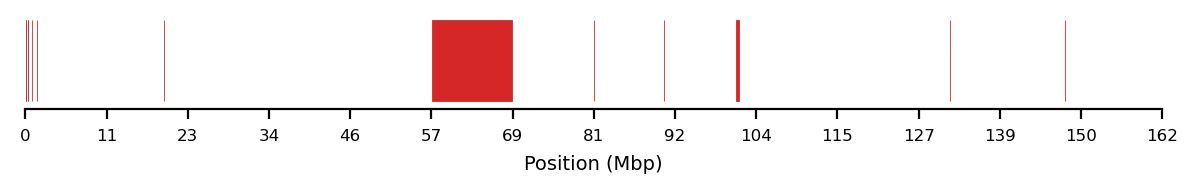

In [ ]:
#| echo: false
#| label: "fig-t2t-satellites"
#| fig-cap: "Satellite repeats on chrX, inferred from `repeatMasker` file from the T2T-MMU8v1.0 assembly. The centromere is locdated at the largest cluster of satellite repeats, merging intervals within 20kb."

plot_intervals(satellites, lw=0.3, alpha=1)


In [17]:

largest = satellites.loc[satellites['length'].idxmax()]
print(largest)

chrom          CM111679.1
start            57984683
end              69396537
type      ALR/Alpha,HSAT4
length           11411854
Name: 8, dtype: object


### Make a viewframe for cooltools

Here, we partition the chromosome into three parts. 1) small arm, 2) large arm, 3) centromere. The centromere is defined as the region of the chromosome that contains the longest stretch of satellite repeats.

In [79]:
from bioframe import make_viewframe

X_length = rep.query('`Sequence-Name` == "chrX"')['Sequence-Length'].values[0]


view_T2T_MMU8v1_X_chromarms = make_viewframe([('chrX', 0, largest['start'], "small_arm"), 
               ('chrX', largest['start'], largest['end'], 'centromere'),
               ('chrX', largest['end'], X_length, 'large_arm')])

view_T2T_MMU8v1_X_chromarms.to_csv("../data/view_T2T_MMU8v1_X_chromarms.tsv",  index=False, header=False, sep='\t')

### Do the eigendecomposition

Using that viewframe.

In [ ]:
%%bash 

# Find multires coolers
MCOOLS=../steps/cool/*/*.merged.mcool

# Define the viewframe
VIEW=../data/view_T2T_MMU8v1_X_chromarms.tsv

for MCOOL in $MCOOLS; do
    # Get the tissue name
    TISSUE=$(basename $MCOOL .merged.mcool)
    echo $TISSUE
    for res in 1000 5000 10000 50000 100000; do
        COOLER=$MCOOL::resolutions/$res
        GC_BINS=../data/bins/gc.${res}.tsv
        EIGS_OUT=../data/eigs/$TISSUE.eigs.$res

        echo -ne ' -' $res OK
        cooltools eigs-cis -o $EIGS_OUT --view $VIEW --phasing-track $GC_BINS --n-eigs 3 $COOLER

    done
    echo ""
done

echo All done

fibroblast
 - 1000 OK - 5000 OK - 10000 OK - 50000 OK - 100000 OK
pachytene_spermatocyte
 - 1000 OK - 5000 OK - 10000 OK - 50000 OK - 100000 OK
round_spermatid
 - 1000 OK - 5000 OK - 10000 OK - 50000 OK - 100000 OK
spermatogonia
 - 1000 OK - 5000 OK - 10000 OK - 50000 OK - 100000 OK
sperm
 - 1000 OK - 5000 OK - 10000 OK - 50000 OK - 100000 OK
All done


### Check the results by eye

#### Define the eigenvectors

In [4]:
import pandas as pd
from glob import glob
import os

eigfiles = glob("../data/eigs/*vecs.tsv")
eignames = [os.path.basename(eig).split('.cis')[0] for eig in eigfiles]
eignames

df_eig = pd.DataFrame({
    'path': eigfiles,
    'tissue': [eigname.split('.eigs.')[0] for eigname in eignames],
    'resolution': [eigname.split('.eigs.')[1] for eigname in eignames]
})



In [5]:
df_eig['path'].values

array(['../data/eigs/round_spermatid.eigs.1000.cis.vecs.tsv',
       '../data/eigs/spermatogonia.eigs.5000.cis.vecs.tsv',
       '../data/eigs/sperm_X.eigs.50000.cis.vecs.tsv',
       '../data/eigs/round_spermatid.eigs.50000.cis.vecs.tsv',
       '../data/eigs/sperm.eigs.1000.cis.vecs.tsv',
       '../data/eigs/sperm_Y.eigs.500000.cis.vecs.tsv',
       '../data/eigs/fibroblast.eigs.1000.cis.vecs.tsv',
       '../data/eigs/sperm_X.eigs.500000.cis.vecs.tsv',
       '../data/eigs/round_spermatid.eigs.10000.cis.vecs.tsv',
       '../data/eigs/sperm_X.eigs.10000.cis.vecs.tsv',
       '../data/eigs/pachytene_spermatocyte.eigs.1000.cis.vecs.tsv',
       '../data/eigs/sperm_Y.eigs.1000.cis.vecs.tsv',
       '../data/eigs/round_spermatid.eigs.100000.cis.vecs.tsv',
       '../data/eigs/sperm_X.eigs.1000.cis.vecs.tsv',
       '../data/eigs/fibroblast.eigs.10000.cis.vecs.tsv',
       '../data/eigs/spermatogonia.eigs.10000.cis.vecs.tsv',
       '../data/eigs/pachytene_spermatocyte.eigs.100000.cis.v

In [6]:
# Remove sperm_X and sperm_Y
df_eig_mmul = df_eig[~df_eig['tissue'].isin(['sperm_X', 'sperm_Y'])]

sperm_dict = {
    res: pd.read_csv(df_eig_mmul.query('tissue == "sperm" and resolution == @res')['path'].values[0], sep="\t", header=0) for res in df_eig_mmul['resolution'].unique()
}

fib_dict = {
    res: pd.read_csv(df_eig_mmul.query('tissue == "fibroblast" and resolution == @res')['path'].values[0], sep="\t", header=0) for res in df_eig_mmul['resolution'].unique()
}

print(sperm_dict['1000'][495:500])


    chrom   start     end    weight        E1        E2        E3
495  chrX  495000  496000  0.475304 -1.028117  0.017465  0.007392
496  chrX  496000  497000       NaN       NaN       NaN       NaN
497  chrX  497000  498000       NaN       NaN       NaN       NaN
498  chrX  498000  499000  0.366660 -1.025271  0.009784  0.009934
499  chrX  499000  500000       NaN       NaN       NaN       NaN


In [11]:
import matplotlib.pyplot as plt
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('retina')
import numpy as np

plt.style.use('smaller.mplstyle')


# Plot the E1 tracks saved in the sperm_dict

def plot_eigenvectors(eigenvectors, title=None, scatter=True, scatter_alpha=0.5):
    fig, ax = plt.subplots(figsize=(6, 1.1))

    x = eigenvectors['start']
    y = eigenvectors['E1']

    if scatter:
        ax.scatter(x, y, s=0.05, color='k', alpha=scatter_alpha)
    ax.fill_between(x, y, where = y<0, color='tab:blue', lw=1, ec='None')
    ax.fill_between(x, y, where = y>0, color='tab:red', lw=1, ec='None') 
    ax.set_title(title)
    ax.set_ylabel('E1')
    ax.set_xlim(x.min(), x.max())
    ax.set_ylim(-1,1)
    # ax.set_xlabel('Genomic Position (Mbp)')
    ticks = np.linspace(0, x.max(), num=10)
    ax.set_xticks(ticks)
    ax.set_xticklabels([f'{int(t/1e6)} Mb' for t in ticks])
    ax.spines[:].set_visible(False)
    ax.spines['bottom'].set_visible(True)
    fig.tight_layout()


#res = '100000'
#plot_eigenvectors(sperm_dict[res], title=f'Sperm E1 at {int(int(res)/1000)}kb resolution')

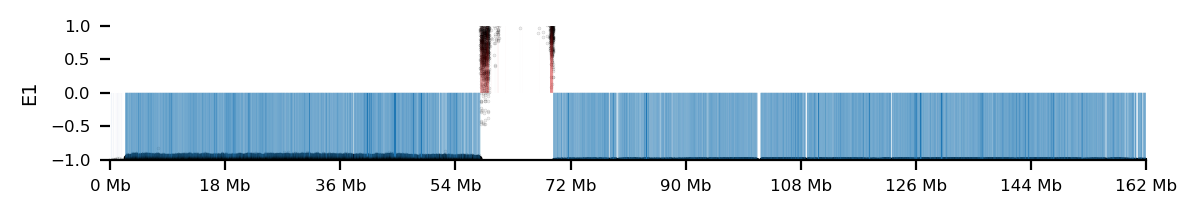

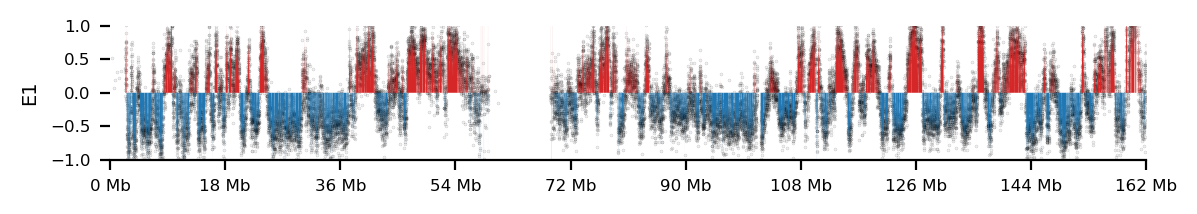

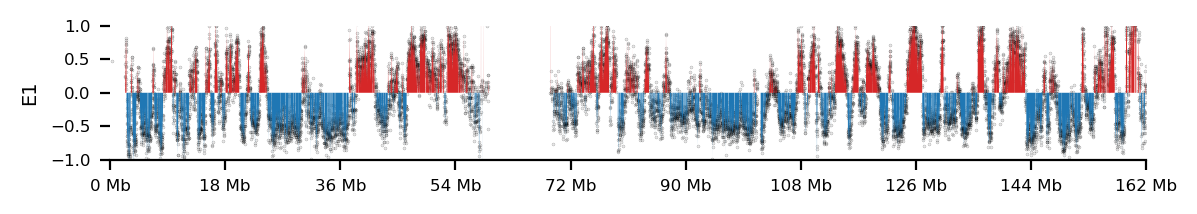

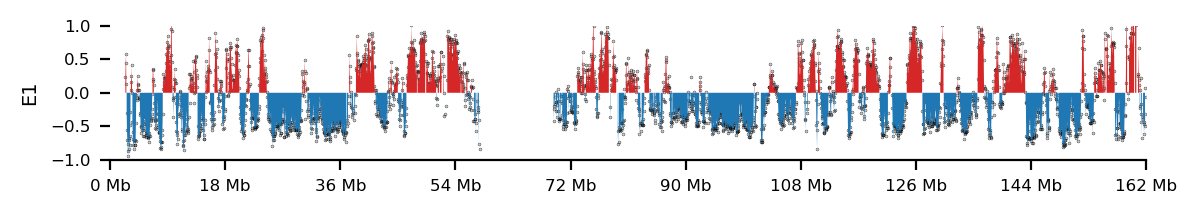

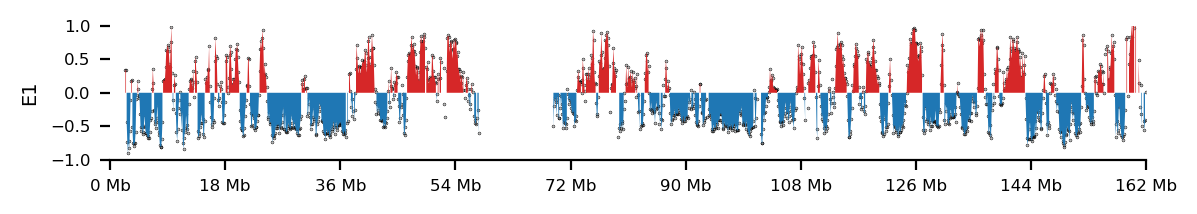

In [19]:
#| echo: false
#| label: "fig-e1-sperm"
#| fig-cap: "E1 eigenvector for T2T-MMU8v1 sperm at different resolutions. The E1 eigenvector is the first eigenvector of the covariance matrix of the Hi-C contact matrix, and it captures the dominant mode of variation in the data. The classical definitions, A: E1 > 0 and B: E1 < 0, are shown in red and blue, respectively. E1 values are overlayed as scatter."
#| fig-subcap: 
#|  - "Sperm E1 at 1kb resolution"
#|  - "Sperm E1 at 5kb resolution"
#|  - "Sperm E1 at 10kb resolution"
#|  - "Sperm E1 at 50kb resolution"
#|  - "Sperm E1 at 100kb resolution"
#| layout-ncol: 1

alpha_list = [0.2, 0.2, 0.3, 0.7, 0.9] # Adjusted alpha for scatter points

for alpha,res in zip(alpha_list,['1000', '5000', '10000', '50000', '100000']):
    plot_eigenvectors(sperm_dict[res], title=None,
                      scatter=True, 
                      scatter_alpha=alpha)

> It looks like the 1kb resolution E1 does not reflect A/B-compartmentalization, but only the variance between the three partitions in the viewframe. 

I don't understand that. The partitioning should eliminate the variance between the three partitions, so this could mean that 

1) there is not much variance within the partitions at this resolution
2) the viewframe is too large 

There are *a lot* of missing values in the 1kb resolution weight and E1, possibly because cooler found that too few contacts were observed to include the bins. That results in a practically unusable E1 track. 

In [6]:
df = pd.read_csv("../data/eigs/fibroblast.eigs.1000.cis.vecs.tsv", sep="\t", header=0)

df.isna().sum()

chrom         0
start         0
end           0
weight    25734
E1        25735
E2        25735
E3        25735
dtype: int64

In [7]:
# Check how many contacts we have on chrX
import cooler
import glob
import os

mclrs = glob.glob("../steps/cool/*/*.merged.mcool")
clrs = [f"{mcl}::/resolutions/100000" for mcl in mclrs]

for clr in clrs:
    tmp_clr = cooler.Cooler(clr)
    print(f"""\
{os.path.basename(clr.split('::')[0])}:
    n_chrX contacts: {tmp_clr.pixels().fetch("chrX")['count'].sum():,}\
""")
    



spermatogonia.merged.mcool:
    n_chrX contacts: 14,285,893
pachytene_spermatocyte.merged.mcool:
    n_chrX contacts: 26,101,166
round_spermatid.merged.mcool:
    n_chrX contacts: 23,848,952
sperm.merged.mcool:
    n_chrX contacts: 12,528,728
fibroblast.merged.mcool:
    n_chrX contacts: 19,244,584


> In hindsight, the 1kb resolution Hi-C matrix is way to sparse to do eigendecomposition. From the metadata sheet, there are a total of $\sim 700,000,000$ Hi-C contacts ($450,000,000$ *cis*). Only a fraction of those are on chrX. 

> Above is the count of total contacts on X on each tissue. It is at most 26,000,000 spread over 160,000 bins at 1kb resolution. That way too sparse to do eigendecomposition.

# EEigendecomposition of human sperm sexchromosome separated samples

Here, we prep the E1 values of the data from the human sperm sexchromosome separated samples.

In [9]:
import bioframe
import cooler
import numpy as np
import pandas as pd

sperm_X = "../../data/human_sperm_haplo_seperated/sperm_X.merged.mcool"
sperm_Y = "../../data/human_sperm_haplo_seperated/sperm_Y.merged.mcool"

In [10]:
# Make viewframes
assembly = "GRCh38"
centromeres = bioframe.fetch_centromeres(assembly)
chromsizes = bioframe.fetch_chromsizes(assembly)
chromarms = bioframe.make_chromarms(chromsizes, centromeres)
view_x = bioframe.make_viewframe(chromarms).query('chrom == "chrX"')
view_y = bioframe.make_viewframe(chromarms).query('chrom == "chrY"')
view_x.to_csv(f"../data/view_{assembly}_X_chromarms.tsv",  index=False, header=False, sep='\t')
view_y.to_csv(f"../data/view_{assembly}_Y_chromarms.tsv",  index=False, header=False, sep='\t')

# Just for views
pd.concat([view_x, view_y])

,chrom,start,end,name
44,chrX,0,61000000,chrX_p
45,chrX,61000000,156040895,chrX_q
46,chrY,0,10400000,chrY_p
47,chrY,10400000,57227415,chrY_q


## Calculate the GC contetn coverage


In [ ]:
%%bash 

REF=../../data/human_sperm_haplo_seperated/references/GRCh38.fa

for res in 1000 5000 10000 50000 100000; do
    BINS=../data/bins/hg38.bins.${res}.tsv
    GC_OUT=../data/bins/hg38.gc.${res}.tsv
    cooltools genome gc $BINS $REF > $GC_OUT
done

## Do eigendecomposition

In [1]:
%%bash 

# Find multires coolers
SPERM_X="../../data/human_sperm_haplo_seperated/sperm_X.merged.mcool"
SPERM_Y="../../data/human_sperm_haplo_seperated/sperm_Y.merged.mcool"

# Define the viewframe
VIEW_X=../data/view_GRCh38_X_chromarms.tsv
VIEW_Y=../data/view_GRCh38_Y_chromarms.tsv

# Names
SAMPLE_X=$(basename $SPERM_X .merged.mcool)
SAMPLE_Y=$(basename $SPERM_Y .merged.mcool)

echo $SAMPLE_X
for res in 1000 5000 10000 50000 100000 500000; do
    echo $res
    COOLER=$SPERM_X::resolutions/$res
    GC_BINS=../data/bins/hg38.gc.${res}.tsv
    EIGS_OUT=../data/eigs/$SAMPLE_X.eigs.$res

    echo -ne ' -' $res OK
    cooltools eigs-cis -o $EIGS_OUT --view $VIEW_X --phasing-track $GC_BINS --n-eigs 3 $COOLER

done
echo ""

echo $SAMPLE_Y
for res in 1000 5000 10000 50000 100000 500000; do
    echo $res
    COOLER=$SPERM_Y::resolutions/$res
    GC_BINS=../data/bins/hg38.gc.${res}.tsv
    EIGS_OUT=../data/eigs/$SAMPLE_Y.eigs.$res

    echo -ne ' -' $res OK
    cooltools eigs-cis -o $EIGS_OUT --view $VIEW_Y --phasing-track $GC_BINS --n-eigs 3 $COOLER

done
echo ""

echo All done

sperm_X
1000


/home/sojern/miniconda3/envs/hic/lib/python3.12/site-packages/cooltools/cli/eigs_cis.py:143: FutureWarning: The 'verbose' keyword in pd.read_table is deprecated and will be removed in a future version.
  track_df = pd.read_table(


 - 1000 OK5000


/home/sojern/miniconda3/envs/hic/lib/python3.12/site-packages/cooltools/cli/eigs_cis.py:143: FutureWarning: The 'verbose' keyword in pd.read_table is deprecated and will be removed in a future version.
  track_df = pd.read_table(


 - 5000 OK10000


...

 - 50000 OK100000


/home/sojern/miniconda3/envs/hic/lib/python3.12/site-packages/cooltools/cli/eigs_cis.py:143: FutureWarning: The 'verbose' keyword in pd.read_table is deprecated and will be removed in a future version.
  track_df = pd.read_table(


 - 100000 OK500000


/home/sojern/miniconda3/envs/hic/lib/python3.12/site-packages/cooltools/cli/eigs_cis.py:143: FutureWarning: The 'verbose' keyword in pd.read_table is deprecated and will be removed in a future version.
  track_df = pd.read_table(


 - 500000 OK
All done


In [13]:

sperm_X_dict = {
    res: pd.read_csv(df_eig.query('tissue == "sperm_X" and resolution == @res')['path'].values[0], sep="\t", header=0) for res in df_eig['resolution'].unique()
}


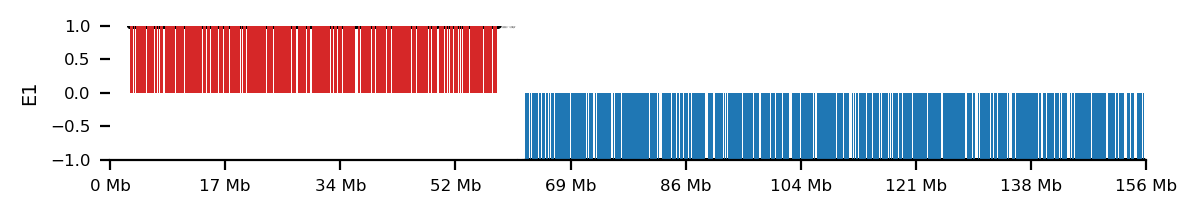

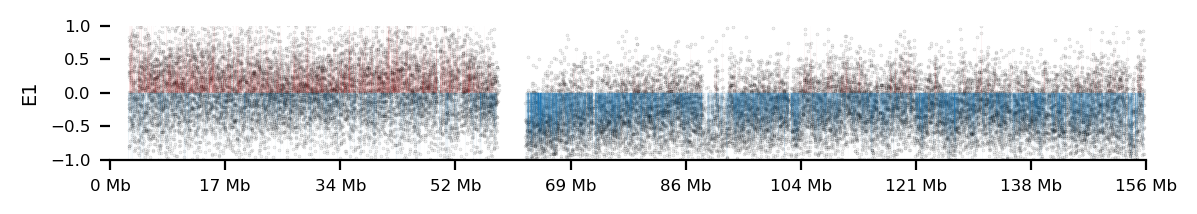

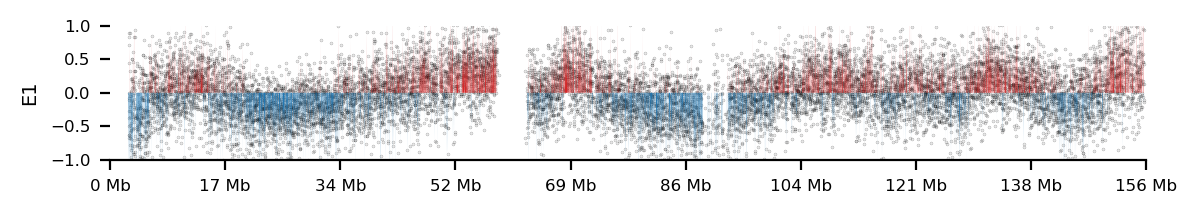

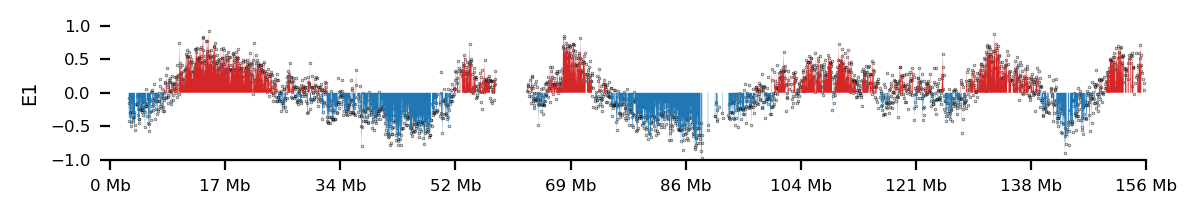

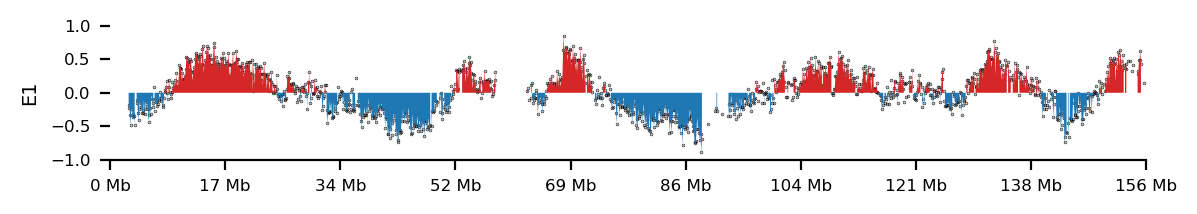

In [18]:
#| echo: false
#| label: "fig-e1-sperm-x"
#| fig-cap: "E1 eigenvector for human GRCh37 sperm at different resolutions. The E1 eigenvector is the first eigenvector of the covariance matrix of the Hi-C contact matrix, and it captures the dominant mode of variation in the data. The classical definitions, A: E1 > 0 and B: E1 < 0, are shown in red and blue, respectively. E1 values are overlayed as scatter."
#| fig-subcap:
#|  - "1kb resolution"
#|  - "5kb resolution"
#|  - "10kb resolution"
#|  - "50kb resolution"
#|  - "100kb resolution"
#| layout-ncol: 1

alpha_list = [0.2, 0.2, 0.3, 0.7, 0.9] # Adjusted alpha for scatter points

for alpha,res in zip(alpha_list,['1000', '5000', '10000', '50000', '100000']):
    plot_eigenvectors(sperm_X_dict[res], 
                      title=None,
                      scatter=True,
                      scatter_alpha=alpha)

#### Check the valid interaction counts

In [10]:
import cooler
import glob
import os

mclrs = glob.glob("../../data/human_sperm_haplo_seperated/sperm_X.merged.mcool")
clrs = [f"{mcl}::/resolutions/100000" for mcl in mclrs]

for clr in clrs:
    tmp_clr = cooler.Cooler(clr)
    print(f"""\
{os.path.basename(clr.split('::')[0])}:
    n_chrX contacts: {tmp_clr.pixels().fetch("chrX")['count'].sum():,}\
""")
    


sperm_X.merged.mcool:
    n_chrX contacts: 3,493,029
